# Exercise 1

- Chuyển ảnh màu sáng sang màu tối với phương pháp lightness

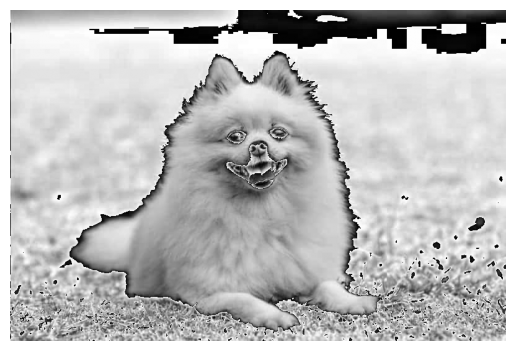

In [177]:
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread('dog.jpeg')
gray_img_01 = (img.max(axis=2) + img.min(axis=2)) / 2
gray_img_01[0, 0]

plt.imshow(gray_img_01, cmap='gray')
plt.axis('off')
plt.show()

- Average

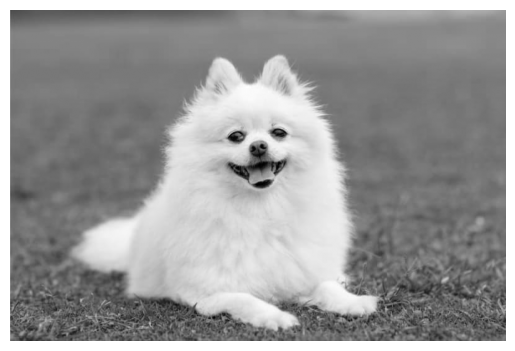

In [178]:
gray_img_02 = img.mean(axis=2)
round(gray_img_02[0, 0], 1)
plt.imshow(gray_img_02, cmap='gray')
plt.axis('off')
plt.show()

- Luminosity

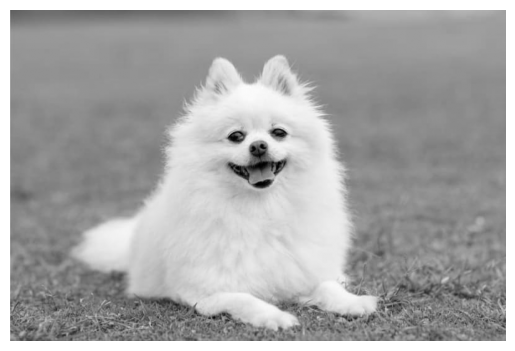

In [179]:
#v1
gray_img_03 = 0.21 * img[:, :, 0] + 0.72 * img[:, :, 1] + 0.07 * img[:, :, 2]    
round(gray_img_03[0, 0], 1)

import numpy as np
#v2
gray_img_04 = np.dot(img[:, :, :3], [0.21, 0.72, 0.07])
round(gray_img_04[0, 0], 1)
plt.imshow(gray_img_03, cmap='gray')
plt.axis('off')
plt.show()


# Exercise 2

In [180]:
import pandas as pd
df = pd.read_csv('advertising.csv')
df.head(5)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


- Lấy giá trị max và chỉ số mục tương ứng trên cột Sales

In [181]:
data =  df.to_numpy()
sales_col = data[:, 3]
max_sales = np.max(sales_col)
index_max = np.argmax(sales_col)
print(f'Max: {max_sales} - Index_max: {index_max}')


Max: 27.0 - Index_max: 175


- Giá trị trung bình cột TV

In [182]:
tv_cols = data[:, 0]
res = np.mean(tv_cols)
print(f'Avg values of tv: {res}')   

Avg values of tv: 147.0425


- Số lượng bản ghi có giá trị tại cột sales >= 20 là

In [183]:
count = np.sum(sales_col >= 20)
print(f'Số lượng bản ghi có Sales >= 20: {count}')


Số lượng bản ghi có Sales >= 20: 40


- Giá trị trung bình của cột Radio điều kiện cột sales >= 15

In [184]:
radio_cols = data[:, 1]
condition = sales_col >= 15
radio_mean = np.mean(radio_cols[condition])
print(round(radio_mean, 1))

26.2


- Tổng các hàng của cột sales với đk giá trị newspaper > mean của cột newsppaper

In [185]:
news_cols = data[:, 2]
news_mean = np.mean(news_cols)
condition = news_cols > news_mean
sum_rows_sales = np.sum(sales_col[condition])
print(sum_rows_sales)

1405.1


In [186]:
A = np.mean(sales_col)
conditions = [
    sales_col > A,
    sales_col < A,
    sales_col == A
]

choices = ['Good', 'Bad', 'Average']
scores = np.select(conditions, choices, default='Average')
print(scores[7:10])

['Bad' 'Bad' 'Good']


In [187]:
dist = np.abs(sales_col - A)
closest_index = np.argmin(dist)
A_new = sales_col[closest_index]
conditions_new = [
    sales_col > A,
    sales_col < A, 
    sales_col == A
]

scores_new = np.select(conditions_new, choices, default='Average')
print(scores_new[7:10])

['Bad' 'Bad' 'Good']
